# Wave equation in an interval

In [ ]:
from typing import Callable
import numpy as np
from lucifex.mesh import interval_mesh
from lucifex.fem import Constant, Function
from lucifex.fdm import (
    FiniteDifference, FiniteDifferenceArgwise, FunctionSeries, ConstantSeries, 
    CN, finite_difference_order, advective_timestep,
)
from lucifex.solver import ibvp, evaluation , BoundaryConditions
from lucifex.sim import Simulation, run
from lucifex.plt import plot_line, save_figure
from lucifex.utils.py_utils import nested_dict
from lucifex.utils.fenicsx_utils import set_function
from lucifex.pde.wave import wave

def create_simulation(
    Lx: float,
    Nx: int,
    dt: float,
    D_diff: FiniteDifference | FiniteDifferenceArgwise,
    u_zero: Callable,
    u_dot_zero: float | Callable,
) -> Simulation:
    order = finite_difference_order(D_diff, minimum=2)
    mesh = interval_mesh(Lx, Nx)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')
    d = Constant(mesh, 1.0, name='d')
    u = FunctionSeries((mesh, 'P', 1), name='u', order=order, store=1)
    u0 = Function(
        u.function_space, 
        u_zero,
    )
    u0_dot = Function(
        u.function_space, 
        u_dot_zero,
    )
    u.update(u0 - dt * u0_dot)
    u.forward(-float(dt))    
    u_bcs = BoundaryConditions(('dirichlet', lambda x: x[0], 0.0))
    u_solver = ibvp(wave, ics=u_zero, bcs=u_bcs)(u, dt, d, D_diff)
    return Simulation(u_solver, t, dt)


Nx = 100
Lx = 1.0
dt = 0.01
u_zero = lambda x: np.exp(-(x[0] - Lx/2)**2 / (0.01 * Lx))
u_dot_zero = 0.0

simulation = create_simulation(Lx, Nx, dt, CN, u_zero, u_dot_zero)

t_stop = 1.0
n_stop = 50
run(simulation, n_stop, t_stop) 

u = simulation['u']

INFO:root:running build_ext
INFO:root:building 'libffcx_forms_1bb84fdfff7011705f92bb82307b9ee5b5fe9efe' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_1bb84fdfff7011705f92bb82307b9ee5b5fe9efe.c -o ./libffcx_forms_1bb84fdfff7011705f92bb82307b9ee5b5fe9efe.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_1bb84fdfff7011705f92bb82307b9ee5b5fe9efe.o -o ./libffcx_forms_1bb84fdfff7011705f92bb82307b9ee5b5fe9efe.cpython-310-darwin.

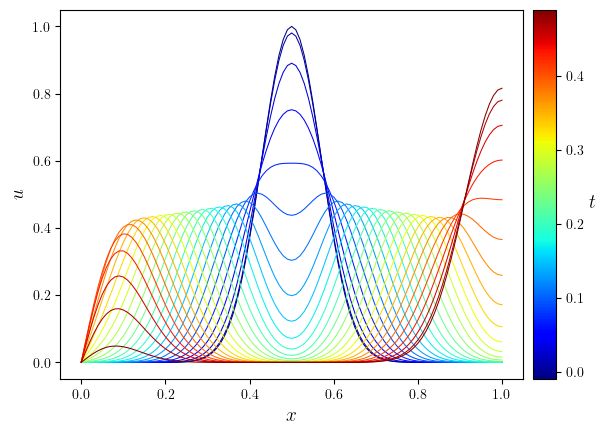

In [ ]:
slc = slice(0, None, 2)
legend_labels=(min(u.time_series[slc]), max(u.time_series[slc]))
fig, ax = plot_line(u.series[slc], legend_labels, '$t$', cyc='jet', x_label='$x$', y_label='$u$')
# save_figure('u(x,t)', thumbnail=True)(fig)